# ExtraaLearn Project Context #

The EdTech industry has been surging in the past decade immensely, and according to a forecast, the Online Education market would be worth $286.62bn by 2023 with a compound annual growth rate (CAGR) of 10.26% from 2018 to 2023. The modern era of online education has enforced a lot in its growth and expansion beyond any limit. Due to having many dominant features like ease of information sharing, personalized learning experience, transparency of assessment, etc, it is now preferable to traditional education.
In the present scenario due to the Covid-19, the online education sector has witnessed rapid growth and is attracting a lot of new customers. Due to this rapid growth, many new companies have emerged in this industry. With the availability and ease of use of digital marketing resources, companies can reach out to a wider audience with their offerings. The customers who show interest in these offerings are termed as leads. There are various sources of obtaining leads for Edtech companies, such as:

The customer interacts with the marketing front on social media or other online platforms.
The customer browses the website/app and downloads the brochure
The customer connects through emails for more information.

The company then nurtures these leads and tries to convert them to paid customers. For this, the representative from the organization connects with the lead on call or through email to share further details.
Objective ExtraaLearn is an initial stage startup that offers programs on cutting-edge technologies to students and professionals to help them upskill/reskill. With a large number of leads being generated on a regular basis, one of the issues faced by ExtraaLearn is to identify which of the leads are more likely to convert so that they can allocate resources accordingly. You, as a data scientist at ExtraaLearn, have been provided the leads data to:

Analyze and build an ML model to help identify which leads are more likely to convert to paid customers,
Find the factors driving the lead conversion process
Create a profile of the leads which are likely to convert

## Data Description ##
The data contains the different attributes of leads and their interaction details with ExtraaLearn. The detailed data dictionary is given below.
Data Dictionary

ID: ID of the lead

age: Age of the lead

current_occupation: Current occupation of the lead. Values include 'Professional','Unemployed',and 'Student'

first_interaction: How did the lead first interacted with ExtraaLearn. Values include 'Website', 'Mobile App'

profile_completed: What percentage of profile has been filled by the lead on the website/mobile app. Values include Low - (0-50%), Medium - (50-75%), High (75-100%)

website_visits: How many times has a lead visited the website

time_spent_on_website: Total time spent on the website

page_views_per_visit: Average number of pages on the website viewed during the visits.

last_activity: Last interaction between the lead and ExtraaLearn.

Email Activity: Seeking for details about program through email, Representative shared information with lead like brochure of program, etc
Phone Activity: Had a Phone Conversation with representative, Had conversation over SMS with representative, etc
Website Activity: Interacted on live chat with representative, Updated profile on website, etc

print_media_type1: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Newspaper.

print_media_type2: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Magazine.

digital_media: Flag indicating whether the lead had seen the ad of ExtraaLearn on the digital platforms.

educational_channels: Flag indicating whether the lead had heard about ExtraaLearn in the education channels like online forums, discussion threads, educational websites, etc.

referral: Flag indicating whether the lead had heard about ExtraaLearn through reference.

status: Flag indicating whether the lead was converted to a paid customer or not.

## Importing necessary libraries and data ##

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# To scale the data using z-score
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

# Algorithms to use
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics to evaluate the model
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report,recall_score,precision_score, accuracy_score

# For tuning the model
from sklearn.model_selection import GridSearchCV

# To ignore warnings
import warnings
warnings.filterwarnings("ignore")


In [2]:
# Loading the dataset
data = pd.read_csv('ExtraaLearn.csv')


### Data Overview ###
## Observations: ##

We have 4612 rows and 15 columns in our dataset. There are 4 int type columns (age, website_visits, time_spent_on_website, and status). There are 10 objects (ID, current_occupation, first_interaction, profile_completed, last_activity, print_media_type1, print_media_type2, digital_media, educational_channels, referral). There is one float data type, which is page_views_per_visit


## Sanity checks: ##

We want to see how many unique values and if there are potentially any duplicate rows before we alter any of the data. We can see that there are 4612 unique IDs, which seems like there are no duplicate users in the data set. Additionally, we can sum the duplicated command on our dataset, which should return 0 if there are no duplicate rows.
Since ID is a unique identifier, we know this will not be useful in our model so we can drop this column.


We separate the numerical columns so we can look at the descriptive statistics. We see that the mean age is 46 with a 13 year standard deviation which is pretty large, meaning the data is pretty spread out. The minimum age is 18 and the maximum is 63. Since the median is 51 and greater than the mean, age is left skewed we can comfirm this by looking at the histogram and box plot, where the kde curve is peaking around 60 years. This means that a majority of the data falls within this range, and the lower mean is because there are lower ages pulling the mean down.

website visits has a mean of ~3.6, with a standard deviation of around 2.8. This data is slightly skewed right because the mean is greater than the median (3). The maximum is 30 visits, with the first quartile ranging from 0-2 visits, and the fourth quartile above 5 visits. When we plot the box plot and histogram, we can see that there are some outliers in this column when the number of visits are 10 and above per person.

Time spent on the website has a mean of around 724 and a standard deviation of around 744. This is interesting because the standard deviation is so large, which indicates there are notable differences between time spent on the website between users. We can also see this wide spread by looking at the KDE, quartiles, and minimum and maximum. The minimum time spent is 0, while the maximum is 2537. The median is less than the mean so we know the data is skewed right. The first quartile is between 0 and 148.75, while the second quartile is greater than 148.75 and less than or equal to the median of 376. The third quartile is greater than 376 and less than or equal to 1336.75. The fourth quartile is greater than 1336.75 and less than or equal to the maximum of 2537.5.

Page_views_per_visit is the last numerical value that we do descriptive statistics on. The mean of this variable is around 3 with a standard deviation of around 2 and a median of around 2.8. Since the mean is slightly greater than the median so we know this data is slightly skewed right. We can see from the boxplot and histograms that there is a large number of outliers starting with around 6 and above visits per session. The difference between the bottom of the fourth quartile (75%) and the maximum (18.4) is quite large, so we know there are a few people who have a much higher page per session rate than a majority of the users.

Next, we map the correlation matrix and heat map of the numerical columns. It seems that time spent on the website and status have the highest correlation (0.3), where the more time someone spends on the website the higher the chance they become enrolled. This is an interesting insight that will be important to remember during our decision tree and random forest modeling. The next highest correlation is among age and status, with a correlation of 0.12. The rest of the correlations do not seem to be significant.

In [3]:
#shows first 5 records of dataset
data.head()

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0


In [4]:
#shows the information of the datasets columns like datatype and if there are null values.
#and checks to see if there are the same number of rows for each column. Also shows if there are any null values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4612 non-null   object 
 1   age                    4612 non-null   int64  
 2   current_occupation     4612 non-null   object 
 3   first_interaction      4612 non-null   object 
 4   profile_completed      4612 non-null   object 
 5   website_visits         4612 non-null   int64  
 6   time_spent_on_website  4612 non-null   int64  
 7   page_views_per_visit   4612 non-null   float64
 8   last_activity          4612 non-null   object 
 9   print_media_type1      4612 non-null   object 
 10  print_media_type2      4612 non-null   object 
 11  digital_media          4612 non-null   object 
 12  educational_channels   4612 non-null   object 
 13  referral               4612 non-null   object 
 14  status                 4612 non-null   int64  
dtypes: f

In [5]:
#Shows shape of the dataframe (4612 rows and 15 columns)
data.shape


(4612, 15)

In [6]:
# Calculates the number of unique values per column
#We can see there are 4612 unique IDs, which means we have no repeat users
data.nunique()

ID                       4612
age                        46
current_occupation          3
first_interaction           2
profile_completed           3
website_visits             27
time_spent_on_website    1623
page_views_per_visit     2414
last_activity               3
print_media_type1           2
print_media_type2           2
digital_media               2
educational_channels        2
referral                    2
status                      2
dtype: int64

In [7]:
#Checks to make sure there are no duplicate values in the dataset
data.duplicated().sum()

0

In [8]:
# Drops the ID column, which is a unique identifier and isn't useful for our analysis
data = data.drop(['ID'] , axis = 1)

In [9]:
# Next we will separate our numerical columns from our categorical columns
# Creates numerical columns
num_cols = ['age','website_visits','time_spent_on_website', 'page_views_per_visit']

# creates categorical variables
cat_cols = ['current_occupation', 'first_interaction','profile_completed', 'last_activity',
            'print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral','status']

In [10]:
# Summary statistics of numerical columns
data[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,4612.0,46.201214,13.161454,18.0,36.00000,51.000,57.00000,63.000
website_visits,4612.0,3.566782,2.829134,0.0,2.00000,3.000,5.00000,30.000
time_spent_on_website,4612.0,724.011275,743.828683,0.0,148.75000,376.000,1336.75000,2537.000
page_views_per_visit,4612.0,3.026126,1.968125,0.0,2.07775,2.792,3.75625,18.434


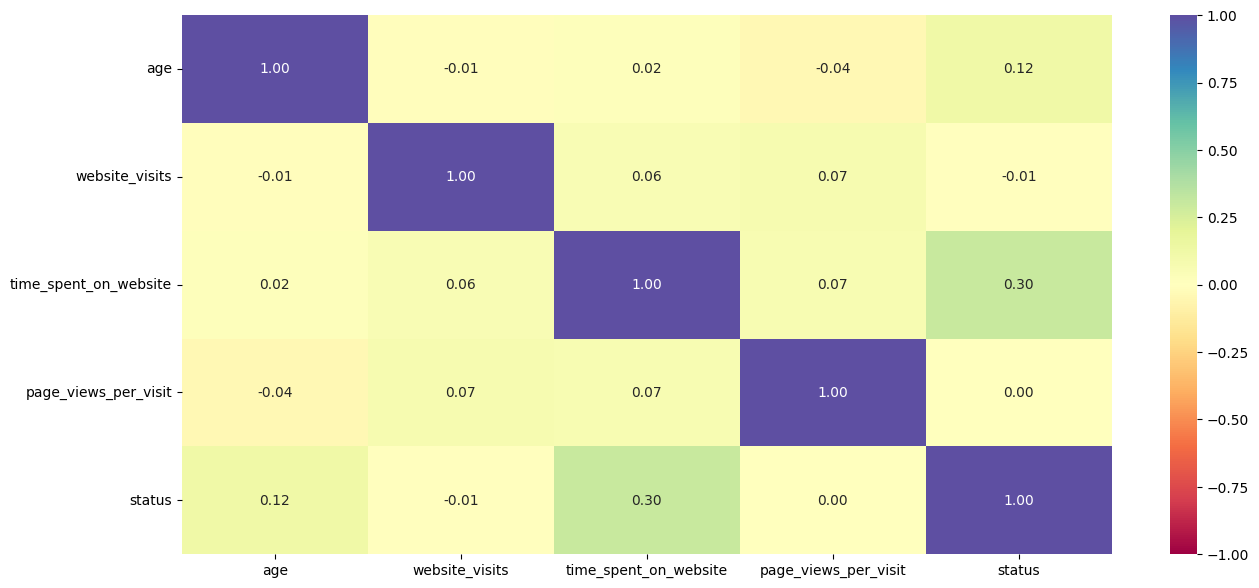

In [11]:
# Only numeric columns (include status here since boolean doesn't matter)
numeric_data = data.select_dtypes(include=np.number)
# Create heatmap
plt.figure(figsize=(15, 7))
sns.heatmap(numeric_data.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

In [12]:
#Plotting histogram and boxplots together on same axis
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):

    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows = 2,      # Number of rows of the subplot grid = 2
        sharex = True,  # x-axis will be shared among all subplots
        gridspec_kw = {"height_ratios": (0.25, 0.75)},
        figsize = figsize,
    )                   # Creating the 2 subplots
    sns.boxplot(data = data, x = feature, ax = ax_box2, showmeans = True, color = "violet"
    )                   # Boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data = data, x = feature, kde = kde, ax = ax_hist2, bins = bins, palette = "winter"
    ) if bins else sns.histplot(
        data = data, x = feature, kde = kde, ax = ax_hist2
    )                   # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color = "green", linestyle = "--"
    )                   # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color = "red", linestyle = "-"
    )                   # Add median to the histogram

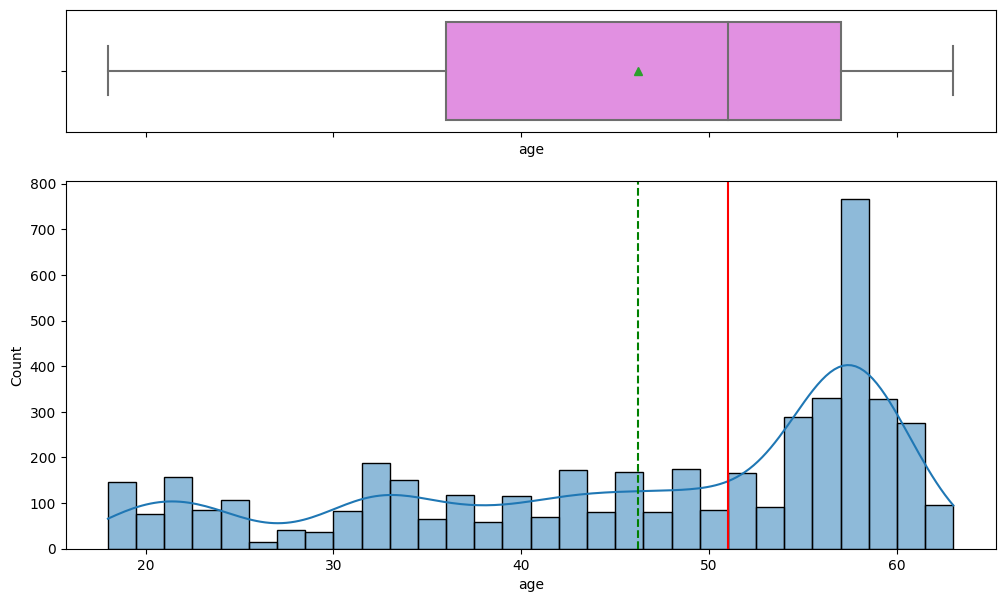

In [13]:
histogram_boxplot(data, "age", kde = True, bins = 30)

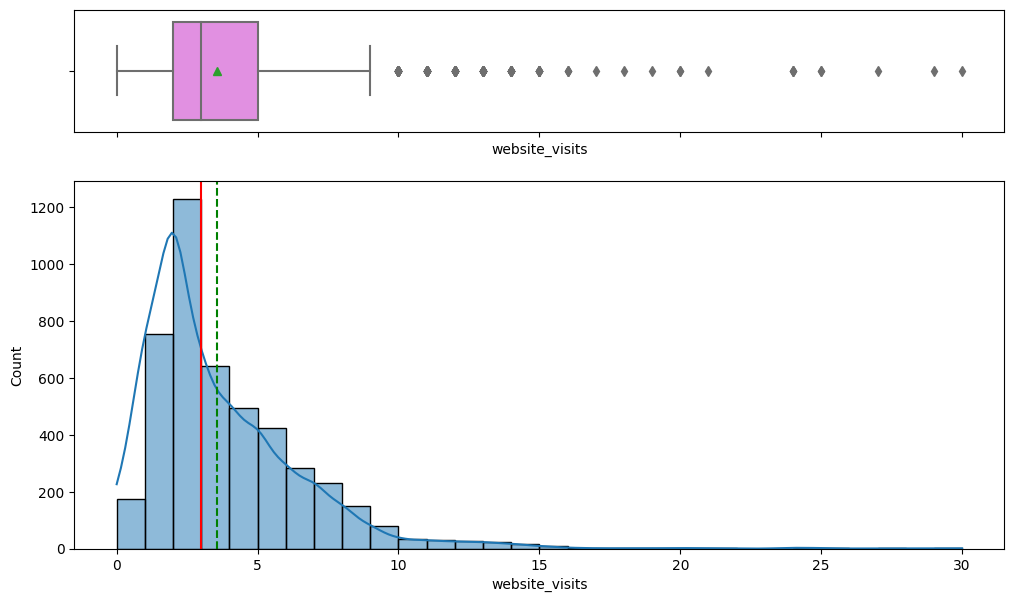

In [14]:
histogram_boxplot(data, "website_visits", kde = True, bins = 30)

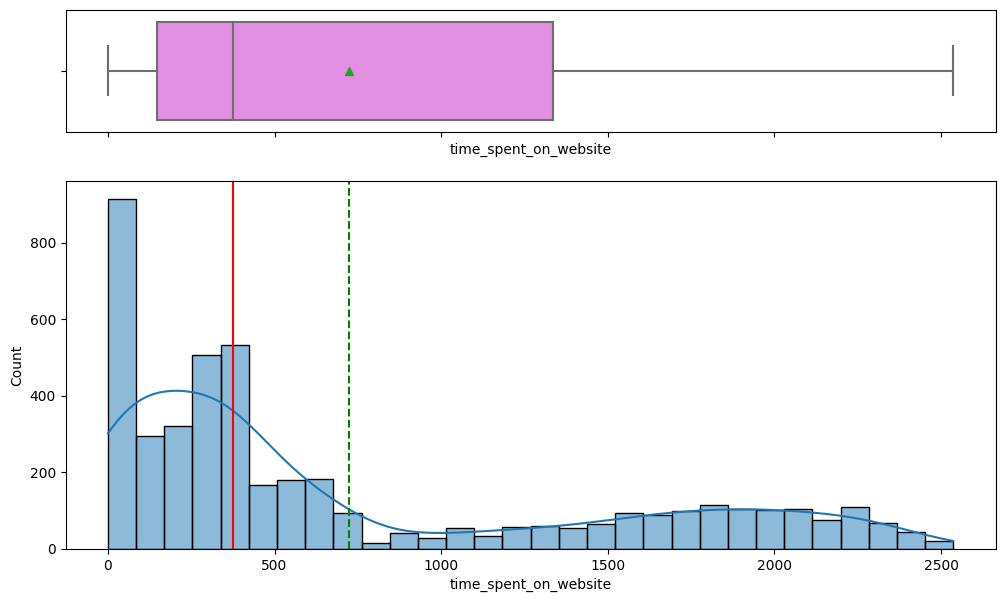

In [15]:
histogram_boxplot(data, "time_spent_on_website", kde = True, bins = 30)


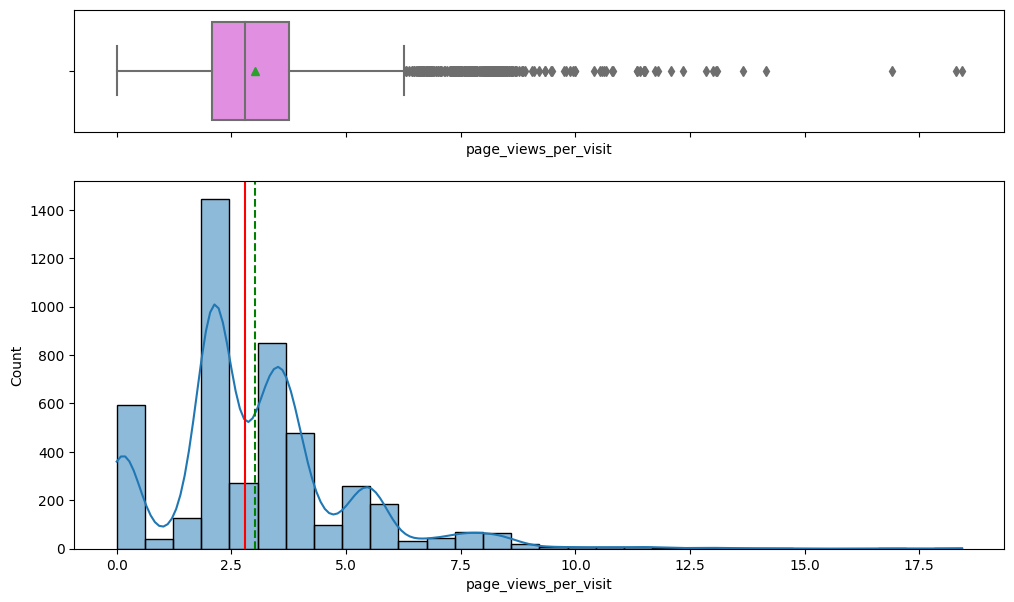

In [16]:
histogram_boxplot(data, "page_views_per_visit", kde = True, bins = 30)


Exploratory Data Analysis (EDA)
EDA is an important part of any project involving data.
It is important to investigate and understand the data better before building a model with it.
A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
A thorough analysis of the data, in addition to the questions mentioned below, should be done.

## Questions ##

Leads will have different expectations from the outcome of the course and the current occupation may play a key role in getting them to participate in the program. Find out how current occupation affects lead status.

By plotting current_occupation and status in a stacked bar and a bar plot, we can see that the highest proportion of people that enroll are currently professionals at around 35% of the total number of professionals being enrolled. The next highest proportion is among the unemployed cohort, with ~27% of the cohort being enrolled. The lowest proportion of those accepted are students, where ~12% are enrolled.


The company's first impression on the customer must have an impact. Do the first channels of interaction have an impact on the lead status?

We can see that people who first interact with the course on the website have a much higher proportion of becoming enrolled (~47%). The mobile app has a much lower conversion rate, around 11%.

### The company uses multiple modes to interact with prospects. Which way of interaction works best? ###
The company uses website activity, email activity, and phone activity. Website activity has the highest conversion rate to enrollment, which leads to around 38% conversion. Email activity, although lower than website activity, has a fairly high conversion rate of around 30%. Phone activity is the lowest, with around a 21% rate of conversion.

### The company gets leads from various channels such as print media, digital media, referrals, etc. Which of these channels have the highest lead conversion rate? ###
Referral has the highest conversion rate, with around 68% of people with a referall enrolling. The reach is not very high however, with only 93 total people receiving a referall in the dataset. Print media type 1 and print media type 2 have the high conversion rates as well, both having around 32% of people converting to paid customers. Print media type 1 has a relatively high reach, with 497 people interacting with this media type and 159 of these 497 people enrolling. print media type 2 has a lower reach, reaching 233 people and 75 of these 233 converting to paid customers. Education channels has the lowest conversion rate with around 28% of people seeing this media type converting. This method reaches the most (705) people.

People browsing the website or mobile application are generally required to create a profile by sharing their personal data before they can access additional information.Does having more details about a prospect increase the chances of conversion?

Profile completed level has a substantial impact on enrollment, those with a high level of profile completeness have a conversion rate of around 42%. The conversion rate falls off with every level of completeness, with around 19% enrolling with a medium level of completeness. Low level of completeness indicates a low level of conversion, with only around 7.5% enrolling.

In [17]:
# How does occupation affect lead status? 
## We can use a stacked bar to show the connection between the binary variable status and current occupation, first we identify 

def stacked_barplot(data, predictor, target):

    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins = True).sort_values(
        by = sorter, ascending = False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize = "index").sort_values(
        by = sorter, ascending = False
    )
    tab.plot(kind = "bar", stacked = True, figsize = (count + 1, 5))
    plt.legend(
        loc = "lower left",
        frameon = False,
    )
    plt.legend(loc = "upper left", bbox_to_anchor = (1, 1))
    plt.show()

status                 0     1   All
current_occupation                  
All                 3235  1377  4612
Professional        1687   929  2616
Unemployed          1058   383  1441
Student              490    65   555
------------------------------------------------------------------------------------------------------------------------


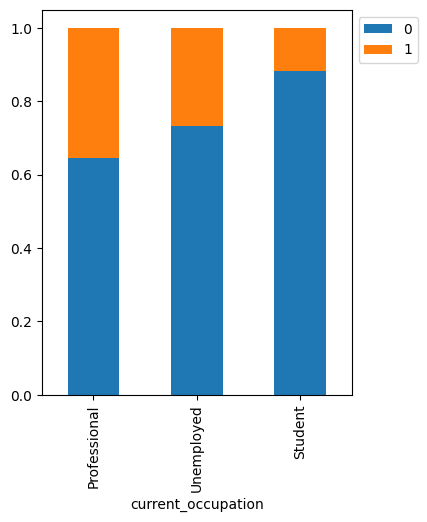

In [18]:
#stacked barplot of current occupation and status
stacked_barplot(data, "current_occupation", "status")

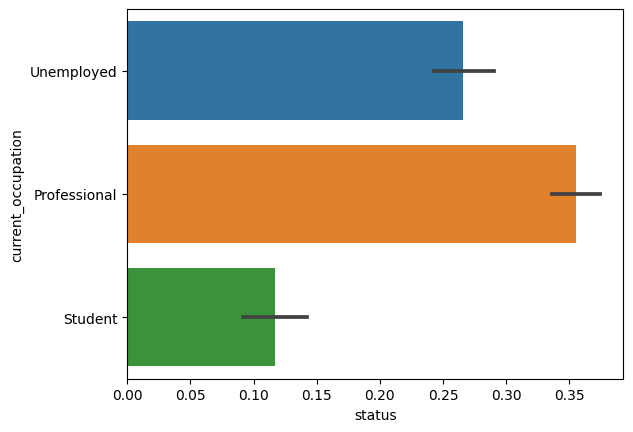

In [19]:
#barplot of current occupation and status
sns.barplot(y = 'current_occupation', x = 'status', data = data)
plt.show()

status                0     1   All
first_interaction                  
All                3235  1377  4612
Website            1383  1159  2542
Mobile App         1852   218  2070
------------------------------------------------------------------------------------------------------------------------


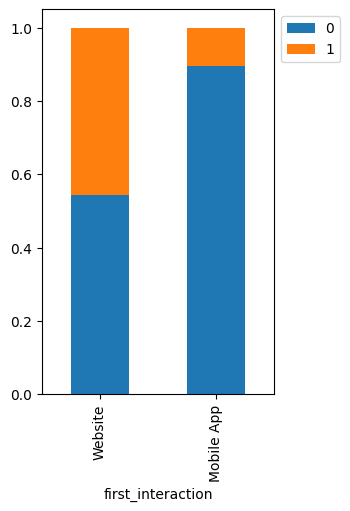

In [20]:
#stacked barplot of first interaction and status
stacked_barplot(data, "first_interaction", "status")

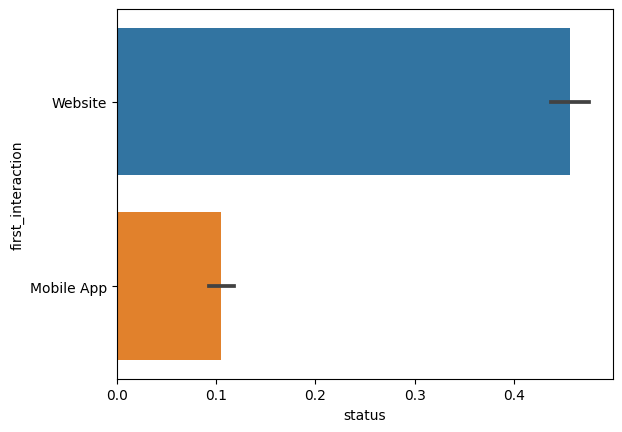

In [21]:
#barplot of first interaction and status
sns.barplot(y = 'first_interaction', x = 'status', data = data)
plt.show()

status               0     1   All
last_activity                     
All               3235  1377  4612
Email Activity    1587   691  2278
Website Activity   677   423  1100
Phone Activity     971   263  1234
------------------------------------------------------------------------------------------------------------------------


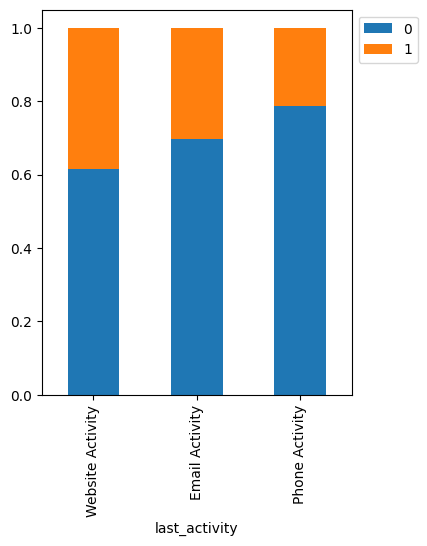

In [22]:
#stacked barplot of last activity and status
stacked_barplot(data, "last_activity", "status")

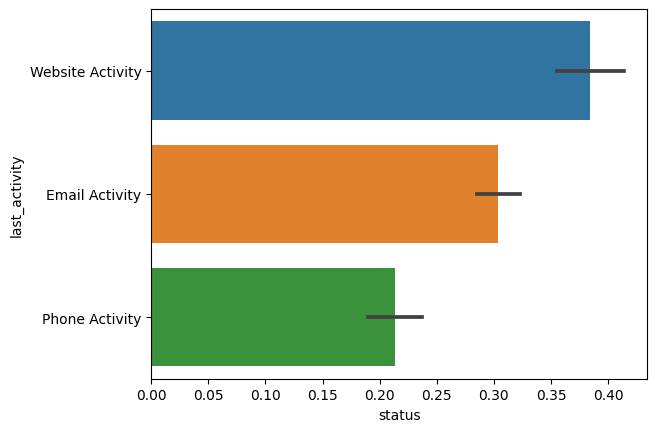

In [23]:
#barplot of last activity and status
sns.barplot(y = 'last_activity', x = 'status', data = data)
plt.show()

status                0     1   All
print_media_type1                  
All                3235  1377  4612
No                 2897  1218  4115
Yes                 338   159   497
------------------------------------------------------------------------------------------------------------------------


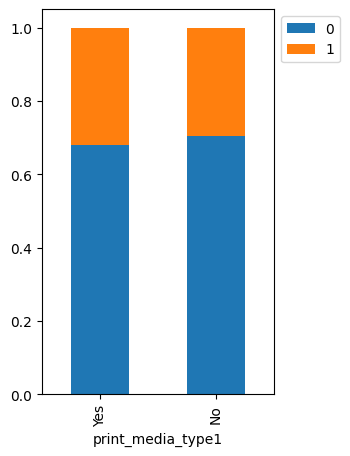

In [24]:
#stacked barplot of print media type 1 and status
stacked_barplot(data, "print_media_type1", "status")

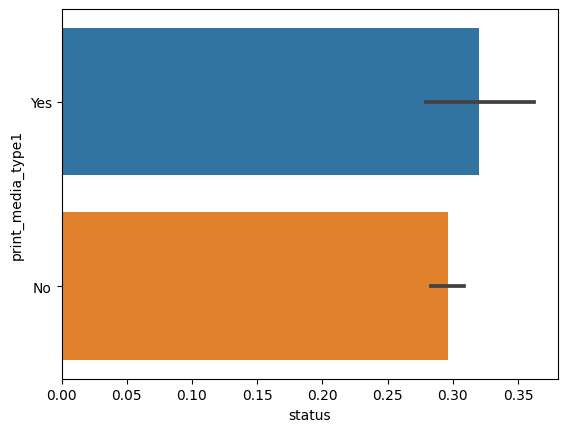

In [25]:
#barplot of print media type 1 and status
sns.barplot(y = 'print_media_type1', x = 'status', data = data)
plt.show()

status                0     1   All
print_media_type2                  
All                3235  1377  4612
No                 3077  1302  4379
Yes                 158    75   233
------------------------------------------------------------------------------------------------------------------------


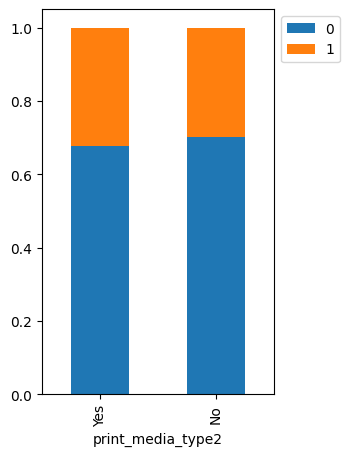

In [26]:
#stacked barplot of print media type 2 and status
stacked_barplot(data, "print_media_type2", "status")

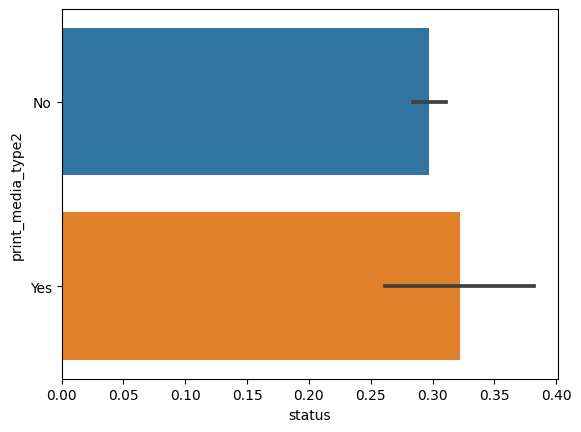

In [27]:
#barplot of print media type 2 and status
sns.barplot(y = 'print_media_type2', x = 'status', data = data)
plt.show()


status                   0     1   All
educational_channels                  
All                   3235  1377  4612
No                    2727  1180  3907
Yes                    508   197   705
------------------------------------------------------------------------------------------------------------------------


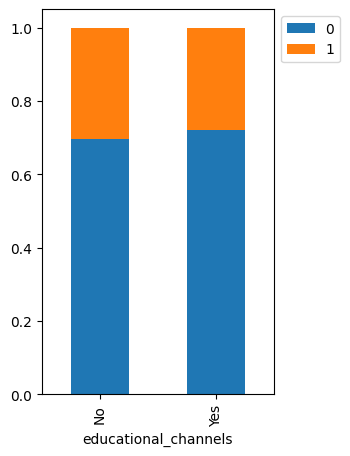

In [28]:
#stacked barplot of education channels and status
stacked_barplot(data, "educational_channels", "status") 


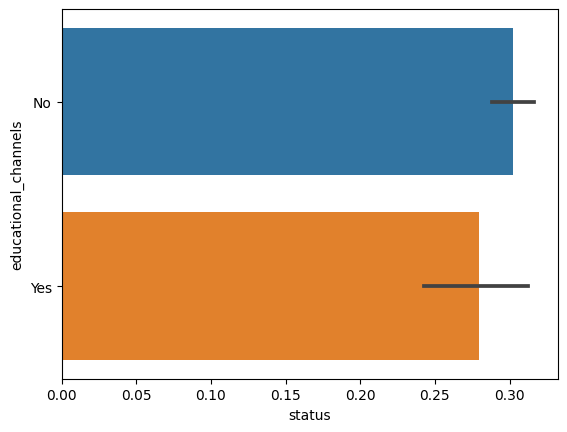

In [29]:
#barplot of education channels and status
sns.barplot(y = 'educational_channels', x = 'status', data = data)
plt.show()

status       0     1   All
referral                  
All       3235  1377  4612
No        3205  1314  4519
Yes         30    63    93
------------------------------------------------------------------------------------------------------------------------


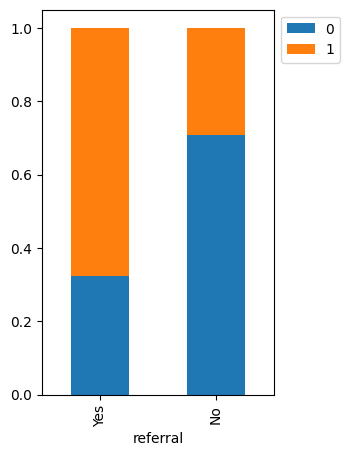

In [30]:
#stacked barplot of referral and status
stacked_barplot(data, "referral", "status")

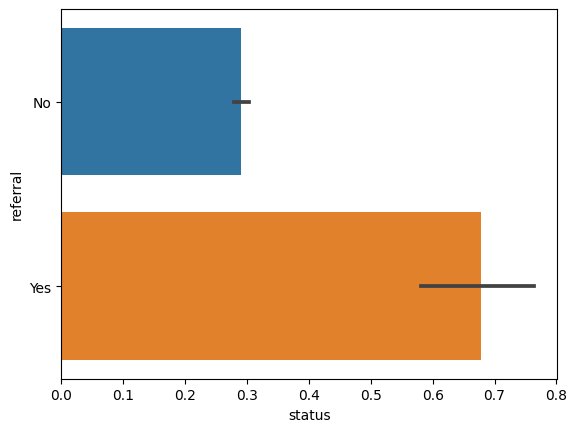

In [31]:
#barplot of referall and status
sns.barplot(y = 'referral', x = 'status', data = data)
plt.show()


status                0     1   All
profile_completed                  
All                3235  1377  4612
High               1318   946  2264
Medium             1818   423  2241
Low                  99     8   107
------------------------------------------------------------------------------------------------------------------------


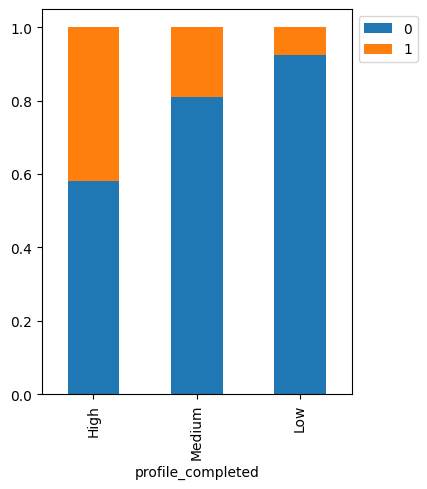

In [32]:
#stacked barplot of profile completed and status
stacked_barplot(data, "profile_completed", "status")

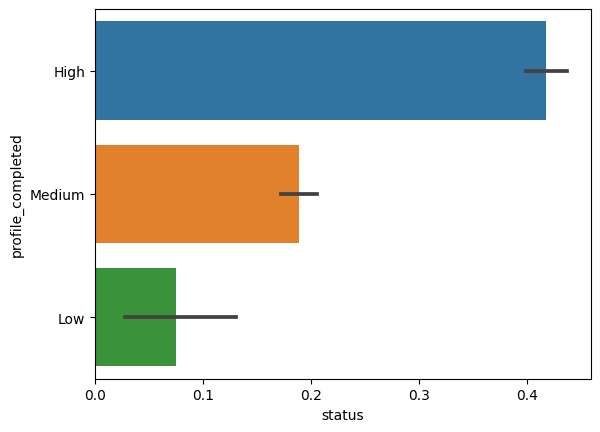

In [33]:
#barplot of profile completed and status
sns.barplot(y = 'profile_completed', x = 'status', data = data)
plt.show()

In [34]:
#prints the value count proportions for all categorical variables
for i in cat_cols:

    print(data[i].value_counts(normalize = True))

    print('*' * 40)


current_occupation
Professional    0.567216
Unemployed      0.312446
Student         0.120338
Name: proportion, dtype: float64
****************************************
first_interaction
Website       0.551171
Mobile App    0.448829
Name: proportion, dtype: float64
****************************************
profile_completed
High      0.490893
Medium    0.485906
Low       0.023200
Name: proportion, dtype: float64
****************************************
last_activity
Email Activity      0.493929
Phone Activity      0.267563
Website Activity    0.238508
Name: proportion, dtype: float64
****************************************
print_media_type1
No     0.892238
Yes    0.107762
Name: proportion, dtype: float64
****************************************
print_media_type2
No     0.94948
Yes    0.05052
Name: proportion, dtype: float64
****************************************
digital_media
No     0.885733
Yes    0.114267
Name: proportion, dtype: float64
****************************************
educ


Observations

The EDA shows us how our variables are distributed. Since we are most curious about how these variables impact status, I have plotted bar charts and stacked bar charts to show the proportion of users that fall into each category that are of status = 1 and status = 0.
From the value count proportions, we are able to get a sense of the distributions of the categorical variables.




Data Preprocessing

Missing value treatment (if needed): N/A (no missing data)
Feature engineering (if needed): Separate status variable (independent) from other variables (dependent) so it doesn't have an impact on the models
Outlier detection and treatment (if needed): Since random forests and decision tree models are robust, I am choosing to not do any outlier treatment because I think this could oversimplify the model
Preparing data for modeling: changing categorical variables into dummy columns
Any other preprocessing steps (if needed): split into test and training data (using 0.7/0.3 split since this isn't a very large dataset)



In [35]:
# Creating dummy variables for the categorical columns
# drop_first=True is used to avoid redundant variables
#There are no missing values in the dataset

to_get_dummies_for = ['current_occupation', 'first_interaction', 'profile_completed', 'last_activity']

# Creating dummy variables
data = pd.get_dummies(data = data, dtype=int, columns = to_get_dummies_for, drop_first = True)

#mapping Yes/No variables to 1/0
dict_print_media_type1 = {'Yes': 1, 'No': 0}
dict_print_media_type2 = {'Yes': 1, 'No': 0}
dict_digital_media = {'Yes': 1, 'No': 0}
dict_educational_channels = {'Yes': 1, 'No': 0}
dict_referral = {'Yes': 1, 'No': 0}

data['print_media_type1'] = data.print_media_type1.map(dict_print_media_type1)
data['print_media_type2'] = data.print_media_type2.map(dict_print_media_type2)
data['digital_media'] = data.digital_media.map(dict_digital_media)
data['educational_channels'] = data.educational_channels.map(dict_educational_channels)
data['referral'] = data.referral.map(dict_referral)
print(data)


      age  website_visits  time_spent_on_website  page_views_per_visit  \
0      57               7                   1639                 1.861   
1      56               2                     83                 0.320   
2      52               3                    330                 0.074   
3      53               4                    464                 2.057   
4      23               4                    600                16.914   
...   ...             ...                    ...                   ...   
4607   35              15                    360                 2.170   
4608   55               8                   2327                 5.393   
4609   58               2                    212                 2.692   
4610   57               1                    154                 3.879   
4611   55               4                   2290                 2.075   

      print_media_type1  print_media_type2  digital_media  \
0                     1                  0        

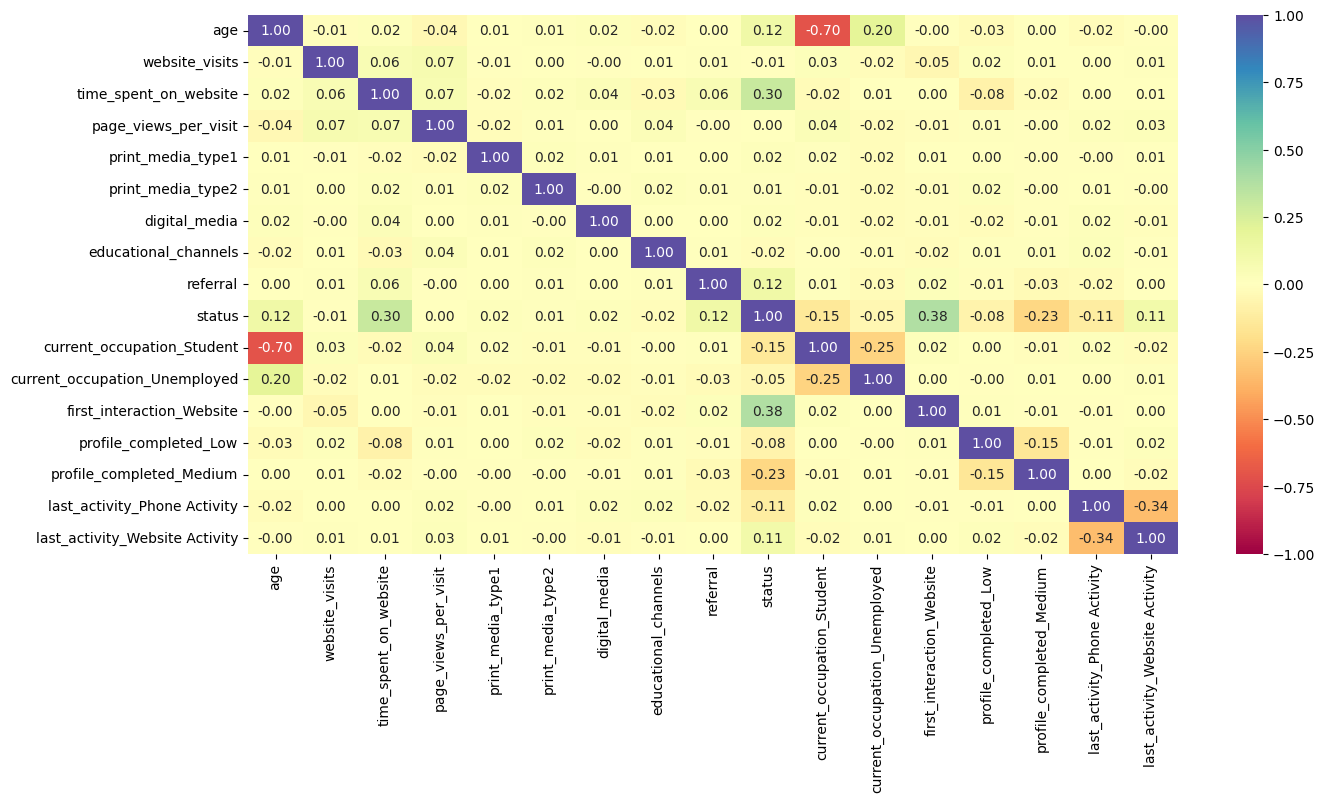

In [36]:
# Create heatmap of all variables once we turn the categorical variables into dummies
plt.figure(figsize=(15, 7))
sns.heatmap(data.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()
#We can see that age and current occupation student is highly negatively correlated, which is expected. The lower the age the higher chance that the 
#user is a student. We can also see that first interaction on the website is poistively correlated with status.
#Overall this correlation matrix shows some interesting considerations, but our decision tree and random forest models
#will be able to give us a much more precise understanding of how the variables are related. 


In [37]:
#Separating the status variable from the rest of the dataset so it doesn't have an impact on the model
Y = data.status  
X = data.drop(['status'], axis = 1)


In [38]:
# Splitting the data into training and test data. Using a 0.7/0.3 split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, random_state = 1, stratify = Y)


In [39]:
# Checking the shape of the train and test data
print("Shape of Training set : ", x_train.shape)
print("Shape of Test set : ", x_test.shape)


Shape of Training set :  (3228, 16)
Shape of Test set :  (1384, 16)


In [40]:
# Creating metric function and confusion matrices
def metrics_score(actual, predicted):
    print(classification_report(actual, predicted))
    cm = confusion_matrix(actual, predicted)
    plt.figure(figsize = (8, 5))
    sns.heatmap(cm, annot = True, fmt = '.2f', xticklabels = ['Does not Convert', 'Converts to Paid'], yticklabels = ['Does not Convert', 'Converts to Paid'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()


In [41]:
#model performance classification function; to evaluate how our models are predicting the data
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance
    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    # Predicting using the independent variables
    pred = model.predict(predictors)
    #computes recall
    recall = recall_score(target, pred,average = 'macro')
    #computes precision
    precision = precision_score(target, pred, average = 'macro')             
    acc = accuracy_score(target, pred)                                 
    # Creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Precision":  precision,
            "Recall":  recall,
            "Accuracy": acc,
        },
        index = [0],
    )
    return df_perf

Building a Decision Tree model

In [42]:
# Building decision tree model with the weights of our status class (upweighting status = 1)
dt = DecisionTreeClassifier(class_weight = {0: 0.3, 1: 0.7}, random_state = 1)

In [43]:
# Fitting decision tree model
dt.fit(x_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.3, 1: 0.7}, random_state=1)


Model Performance evaluation and improvement


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2264
           1       1.00      1.00      1.00       964

    accuracy                           1.00      3228
   macro avg       1.00      1.00      1.00      3228
weighted avg       1.00      1.00      1.00      3228



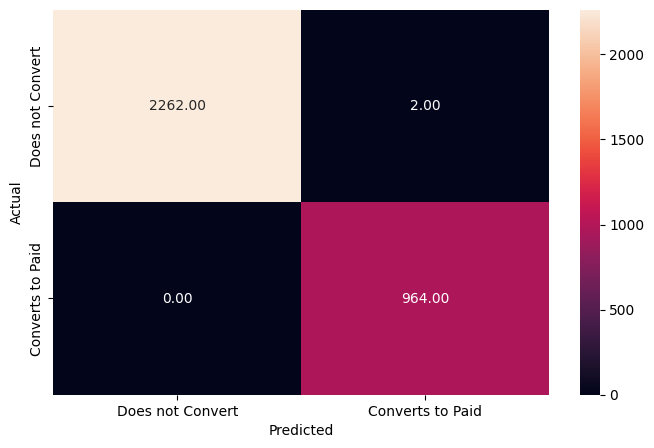

In [44]:
# Checking performance on the training dataset
y_train_pred_dt = dt.predict(x_train)
metrics_score(y_train, y_train_pred_dt)
#We can see that precision/recall/f1 scores are all 100%, which indicates that our model is likely overfitting. 
#We will compare these model scores from the training data to the test data. If they are different, the model is overfitting and needs to be improved.

              precision    recall  f1-score   support

           0       0.84      0.86      0.85       971
           1       0.65      0.62      0.64       413

    accuracy                           0.79      1384
   macro avg       0.75      0.74      0.74      1384
weighted avg       0.79      0.79      0.79      1384



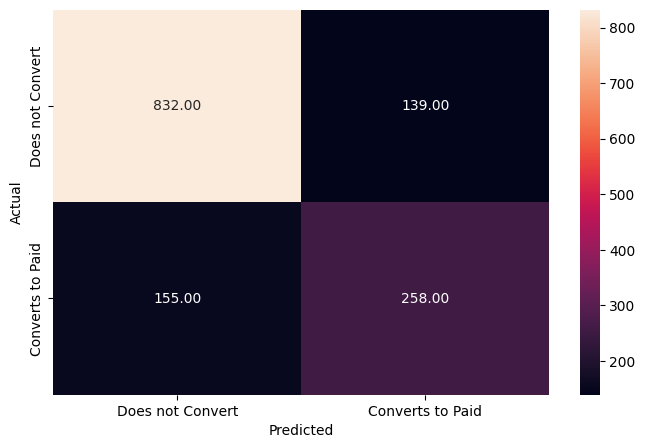

In [45]:
# Checking performance on the test dataset
y_test_pred_dt = dt.predict(x_test)
metrics_score(y_test, y_test_pred_dt)
#we can see here from the precision score of our model that (1-0.65) or 35% of people will be marked as a status = 1 
#or that they are currently enrolled when they actually are not enrolled. This is not a good precision score. The recall and f1 scores on our test data
#are also low, so we know we need to improve the model. 
#We can also see that 1-0.84 = 16% are false negatives, which indicates that they are marked as not enrolled when they are actually enrolled.
#The recall score of 0.62 also shows that there are 62% of people who are actually enrolled were predicted correctly, which is also low 
#(we missed classifying 38% of people who are actually enrolled as enrolled). 
#The f1 score is an average of recall and precision that weighs heavily towards the lower number. 
#In this case the recall and precision are close together, so it makes sense why the f1 score is 0.64. 

In [46]:
dtree_test = model_performance_classification(dt,x_test,y_test)
dtree_test
#this is the overall precision, recall, and accuracy of the model. We notice that these metrics are substanitally lower than they were
#on the training dataset, so we can conclude that the default decision tree model is overfitting the data.
#We also see that accuracy is low, which is a result of false positives and true negatives in the model.

,Precision,Recall,Accuracy
0,0.746416,0.740773,0.787572


[0.08904884 0.04410065 0.26725228 0.12660097 0.00745154 0.00268235
 0.01272779 0.01046446 0.00473332 0.01000062 0.02316935 0.18357281
 0.01473381 0.14933204 0.02330619 0.03082295]


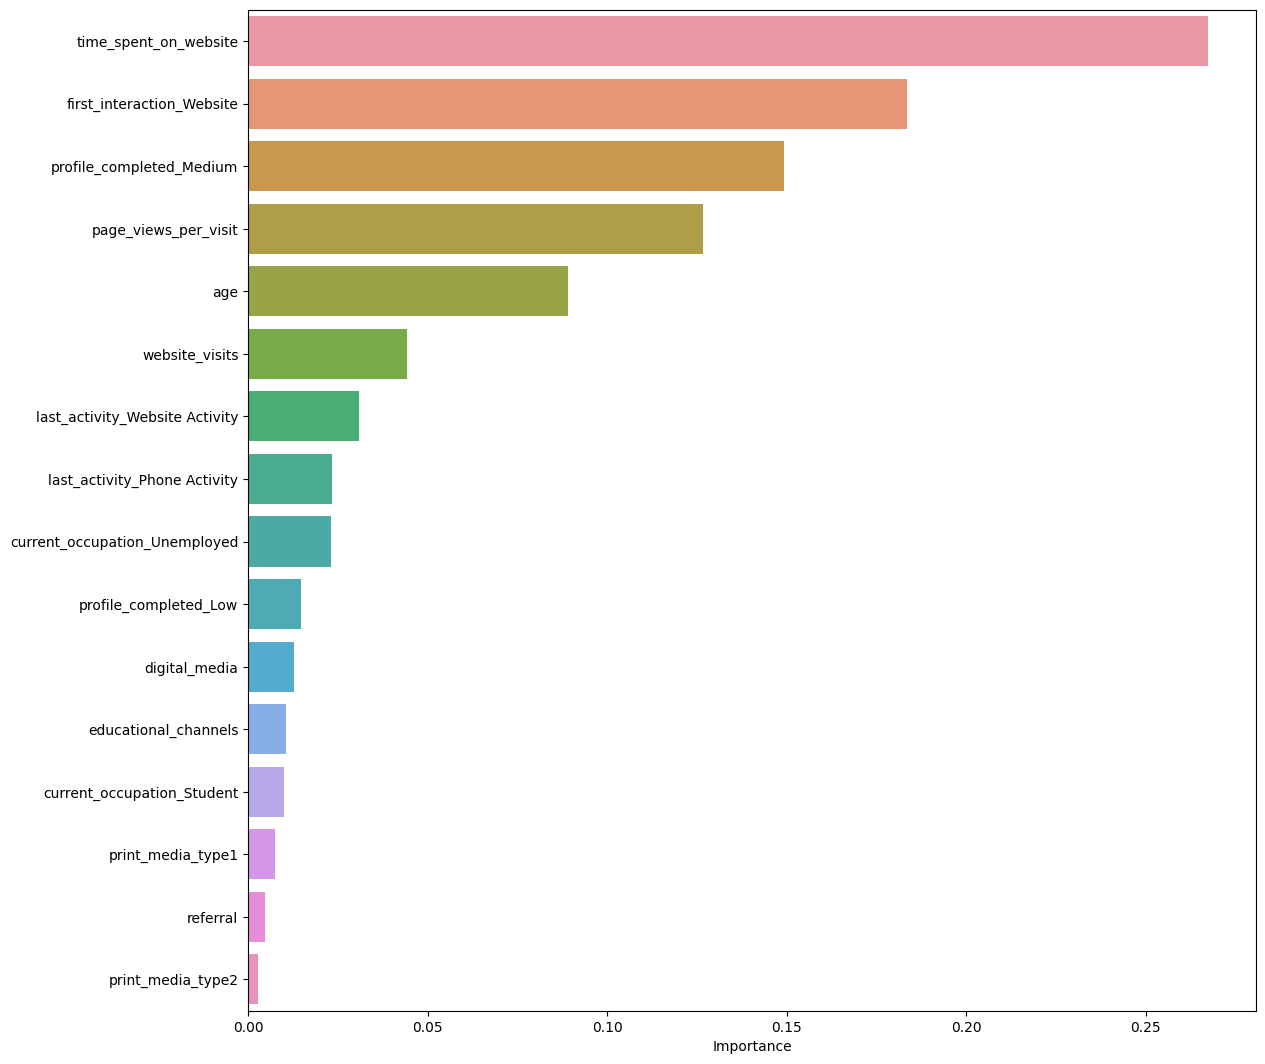

In [47]:
#Now, we plot the importance features to detect which variables in the model are most influencial on status. 
#If a variable is good at predicting status, it will be weigh heavier on importance 
importances = dt.feature_importances_
columns = X.columns
importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)
plt.figure(figsize = (13, 13))
sns.barplot(x=importance_df.Importance,y=importance_df.index);
print(importances)
#We can see that the most important feature is time spent on the website, which has an importance score of 0.26725228. 
#The next most important features are first interaction being on the website, and profile completed level medium is the third most important variable. 
#Page views per visit and age are also important variables. 
#It will be interesting to test the importance of variables on different models. 

In [48]:
# Running gridsearch to optimize hyperparameters of the decision tree
dtree_estimator = DecisionTreeClassifier(class_weight = {0: 0.3, 1: 0.7}, random_state = 1)
# Grid of parameters to choose from in the grid search, will fit model to the best combination
parameters = {'max_depth': np.arange(2, 7),
              'criterion': ['gini', 'entropy'],
              'min_samples_leaf': [5, 10, 20, 25]
             }
# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(recall_score, pos_label = 1)
# Run the grid search
gridCV = GridSearchCV(dtree_estimator, parameters, scoring = scorer, cv = 10)
# Fitting the grid search on the train data
gridCV = gridCV.fit(x_train, y_train)
# Set the classifier to the best combination of parameters
dtree_estimator = gridCV.best_estimator_
# Fit the best estimator to the data
dtree_estimator.fit(x_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.3, 1: 0.7}, max_depth=3,
                       min_samples_leaf=5, random_state=1)

              precision    recall  f1-score   support

           0       0.95      0.75      0.84      2264
           1       0.60      0.91      0.72       964

    accuracy                           0.79      3228
   macro avg       0.78      0.83      0.78      3228
weighted avg       0.85      0.79      0.80      3228



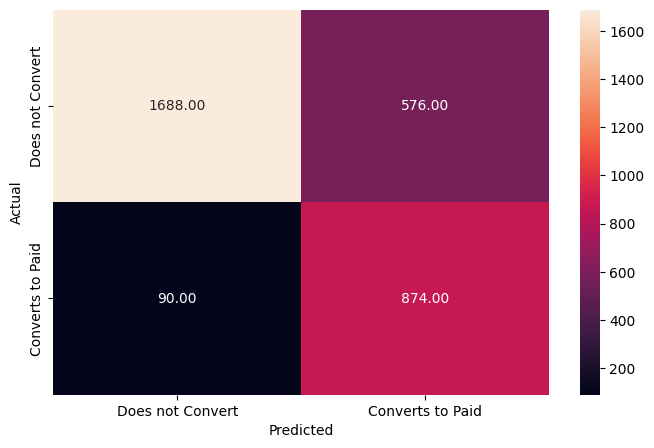

In [49]:
# Checking performance on the training dataset of optimized decision tree
#these scores are lower than the originial decision tree, which suggests that there is less overfitting in this model. 
y_train_pred_dt = dtree_estimator.predict(x_train)
metrics_score(y_train, y_train_pred_dt)

              precision    recall  f1-score   support

           0       0.94      0.73      0.82       971
           1       0.58      0.89      0.70       413

    accuracy                           0.78      1384
   macro avg       0.76      0.81      0.76      1384
weighted avg       0.83      0.78      0.79      1384



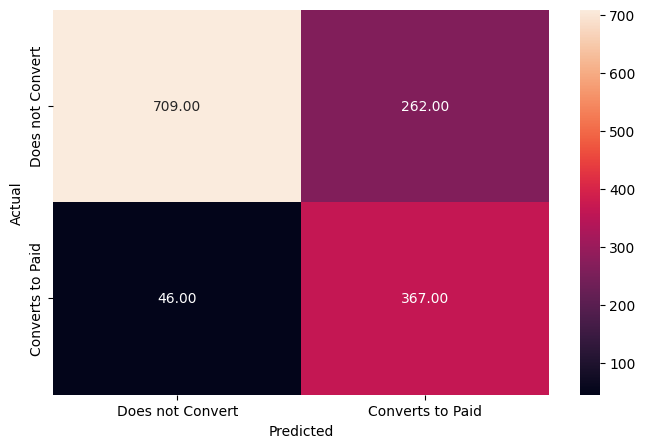

In [50]:
# Checking performance on the test dataset of optimized decision tree
y_test_pred_dt = dtree_estimator.predict(x_test)
metrics_score(y_test, y_test_pred_dt)

In [51]:
dtree_tuned_test = model_performance_classification(dtree_estimator,x_test,y_test)
dtree_tuned_test
#compared to the non-optimized version of the decision tree, we see that precision remains close to the same, recall goes up, and accuracy goes down. 
#Although this is not much improved from the default decision tree model, we see the model perform nearly identically on the training and test data, 
#so we know that we are no longer overfitting.
#Precision has gone down from 0.65 on the default model to 0.58 on the optimized model, so we know there is a high chance that this new model is bias. 
#We can confirm this by looking at the importances for the variables to see the differences between the tuned and default decision tree model. 

,Precision,Recall,Accuracy
0,0.761269,0.809397,0.777457


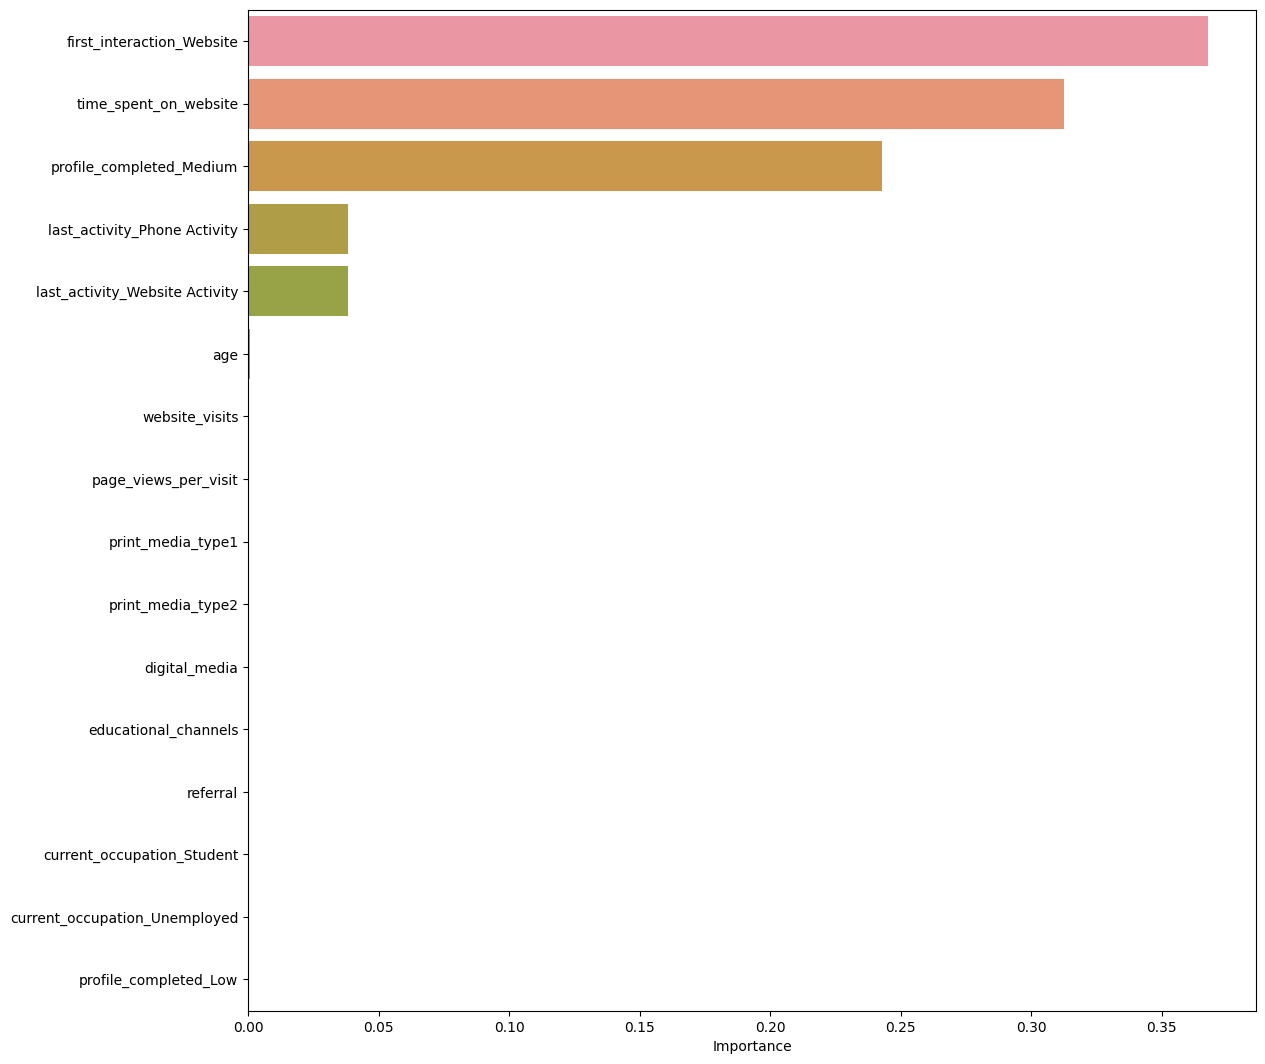

In [52]:
importances = dtree_estimator.feature_importances_
columns = X.columns
importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)
plt.figure(figsize = (13, 13))
sns.barplot(x= importance_df.Importance, y= importance_df.index);
#next we plot the importance matrix for the optimized decision tree. Since this plot has so view variables out of the total being marked as important, 
#we can hypothesize that this tuned decision tree is bias because it is oversimplifying the data and not taking into account many of the other variables 

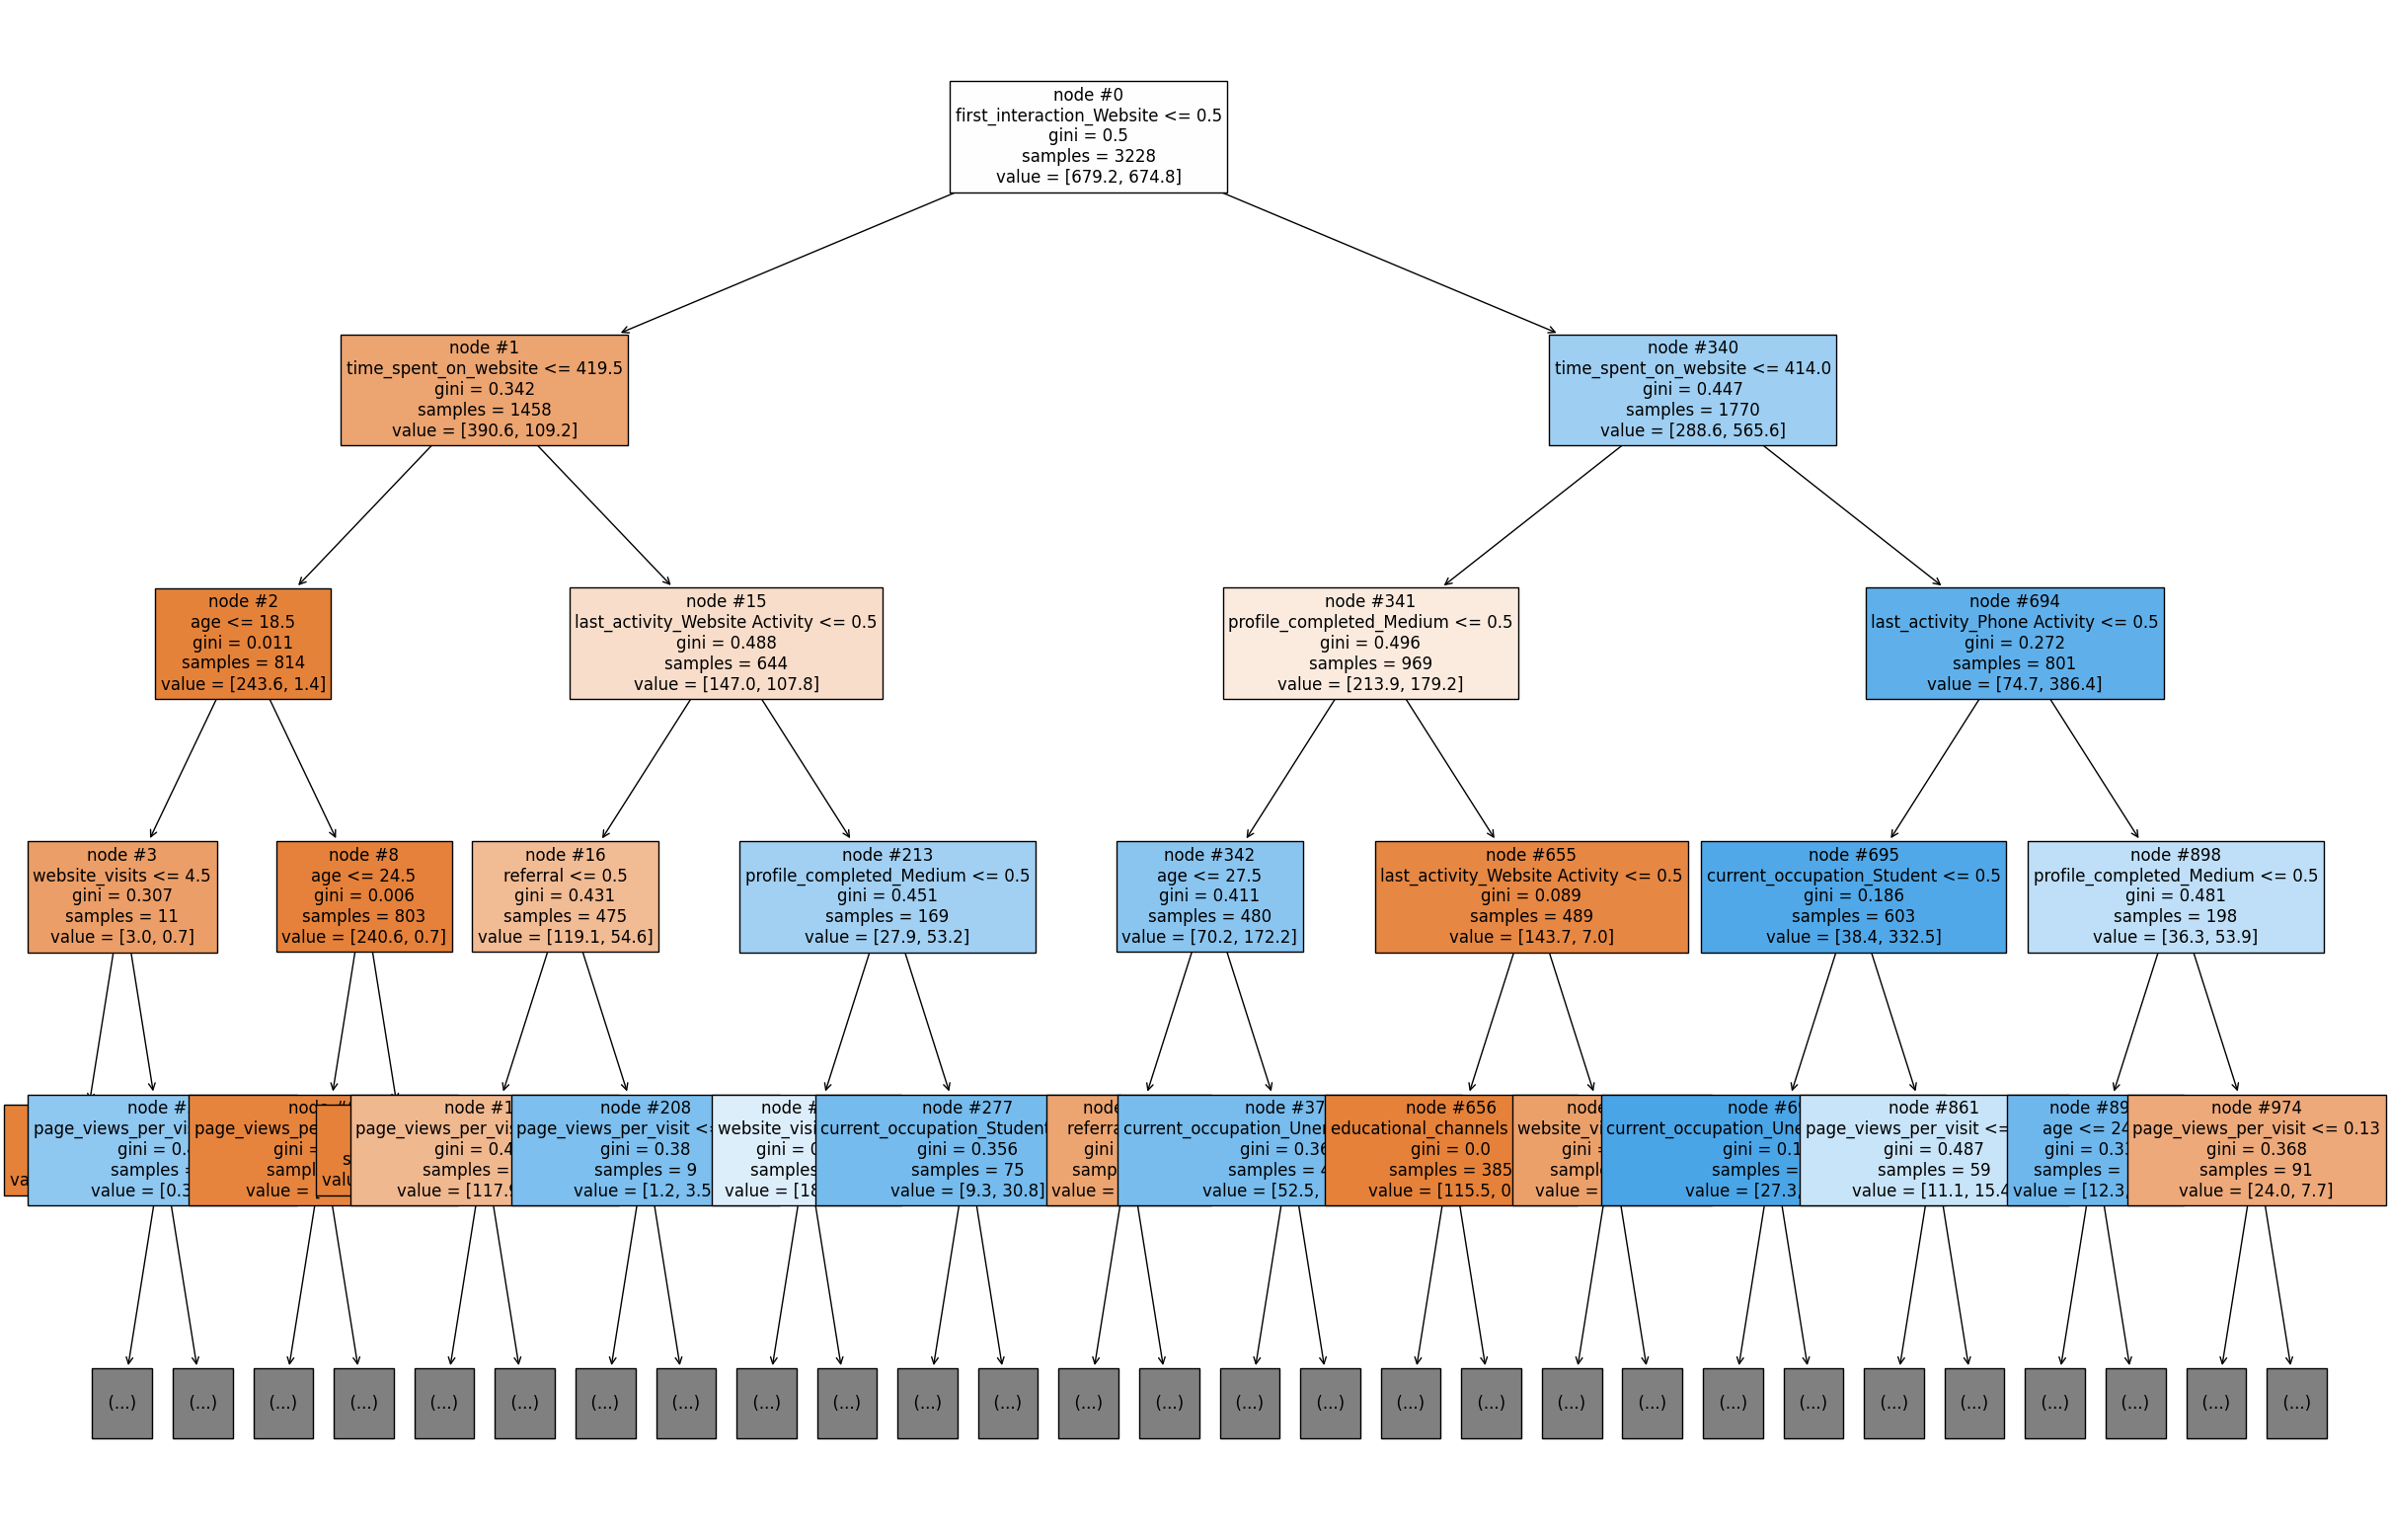

In [53]:
#plots the decision tree
features = list(X.columns)
plt.figure(figsize = (30, 20))
tree.plot_tree(dt, max_depth = 4, feature_names = features, filled = True, fontsize = 12, node_ids = True, class_names = None)
plt.show()

## Observations ##
Node 1: if the first interaction is not on the website, then the majority of cases do not enroll in the program. If the first interaction is on the website, and the time spent on the website is greater than 414 minutes, there is a high chance that the user will be enrolled in in the program.
Blue represents status = 1; red represents status = 0. The darker the color the higher the purity, which means there are a higher proportion of nodes that belong to that specific class.

From our tree, we can see that first interaction being on the website is the highest node impacting whether the user is enrolled or not. When the first action on the website is 1, there is a higher chance that they will then become enrolled.

We also see variables that are more likely to impact users not enrolling in the program. For example, if the user does not first interact on the website, and spends less than 419.5 minutes on the website there is a high chance that they're not going to become enrolled.

The decision tree confirms from our decision tree modeling that first interaction, time spent, and profile completness varaiables have the largest impact on whether or not someone will become enrolled.
Overall, the decision tree model is not great at predicting status. This is because the default model overfits, while the grid search tuned model is bias. It is likely that the decision tree model is too simple for this dataset. We confirm this by the poor accuracy, recall, and accuracy scores on the model. These indicate that the predicitions are falsely marking people as status = 1 when they are not actually enrolled, and status = 0 when they are enrolled.



## Building a Random Forest model ##


In [54]:
# Fitting the Random Forest classifier on the training data
rf_estimator = RandomForestClassifier(class_weight = {0: 0.3, 1: 0.7}, random_state = 1)
rf_estimator.fit(x_train, y_train)


RandomForestClassifier(class_weight={0: 0.3, 1: 0.7}, random_state=1)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2264
           1       1.00      1.00      1.00       964

    accuracy                           1.00      3228
   macro avg       1.00      1.00      1.00      3228
weighted avg       1.00      1.00      1.00      3228



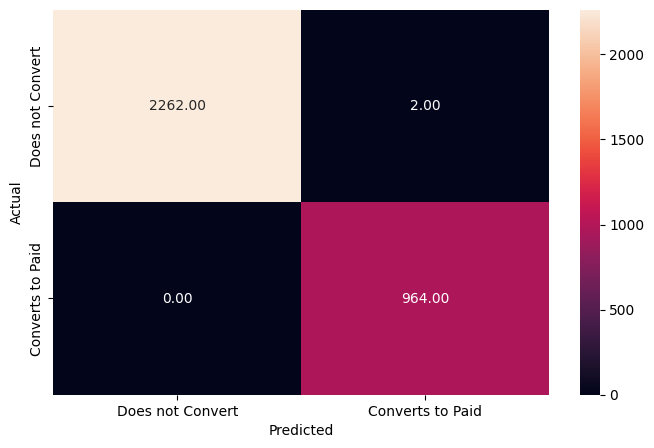

In [55]:
# Checking performance on the training data
#Again, we see 100% scores for the training data. Since saw the same thing on the decision tree modeling, which is similar to
#the random forest model, this is not alarming.
y_pred_train_rf = rf_estimator.predict(x_train)
metrics_score(y_train, y_pred_train_rf)


## Model Performance evaluation and improvement ##

              precision    recall  f1-score   support

           0       0.88      0.91      0.90       971
           1       0.78      0.71      0.74       413

    accuracy                           0.85      1384
   macro avg       0.83      0.81      0.82      1384
weighted avg       0.85      0.85      0.85      1384



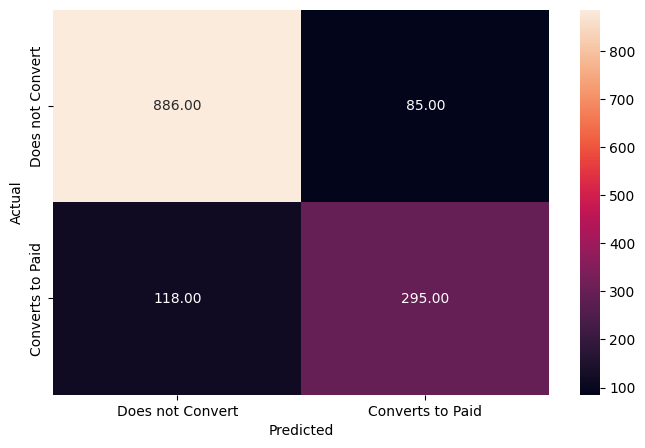

In [56]:
# Checking performance on the testing data
#We see here that precision and recall for status = 1 are both improved, so this is a better fit model.
y_pred_test_rf = rf_estimator.predict(x_test)
metrics_score(y_test, y_pred_test_rf)


In [57]:
#The overall precision, recall, and accuracy are all improved on the random forest model from the decision tree model. 
#This indicates that the random forest model is a better fit for this dataset than a decision tree model.
rf_estimator_test = model_performance_classification(rf_estimator,x_test,y_test)
rf_estimator_test

,Precision,Recall,Accuracy
0,0.829393,0.813374,0.853324


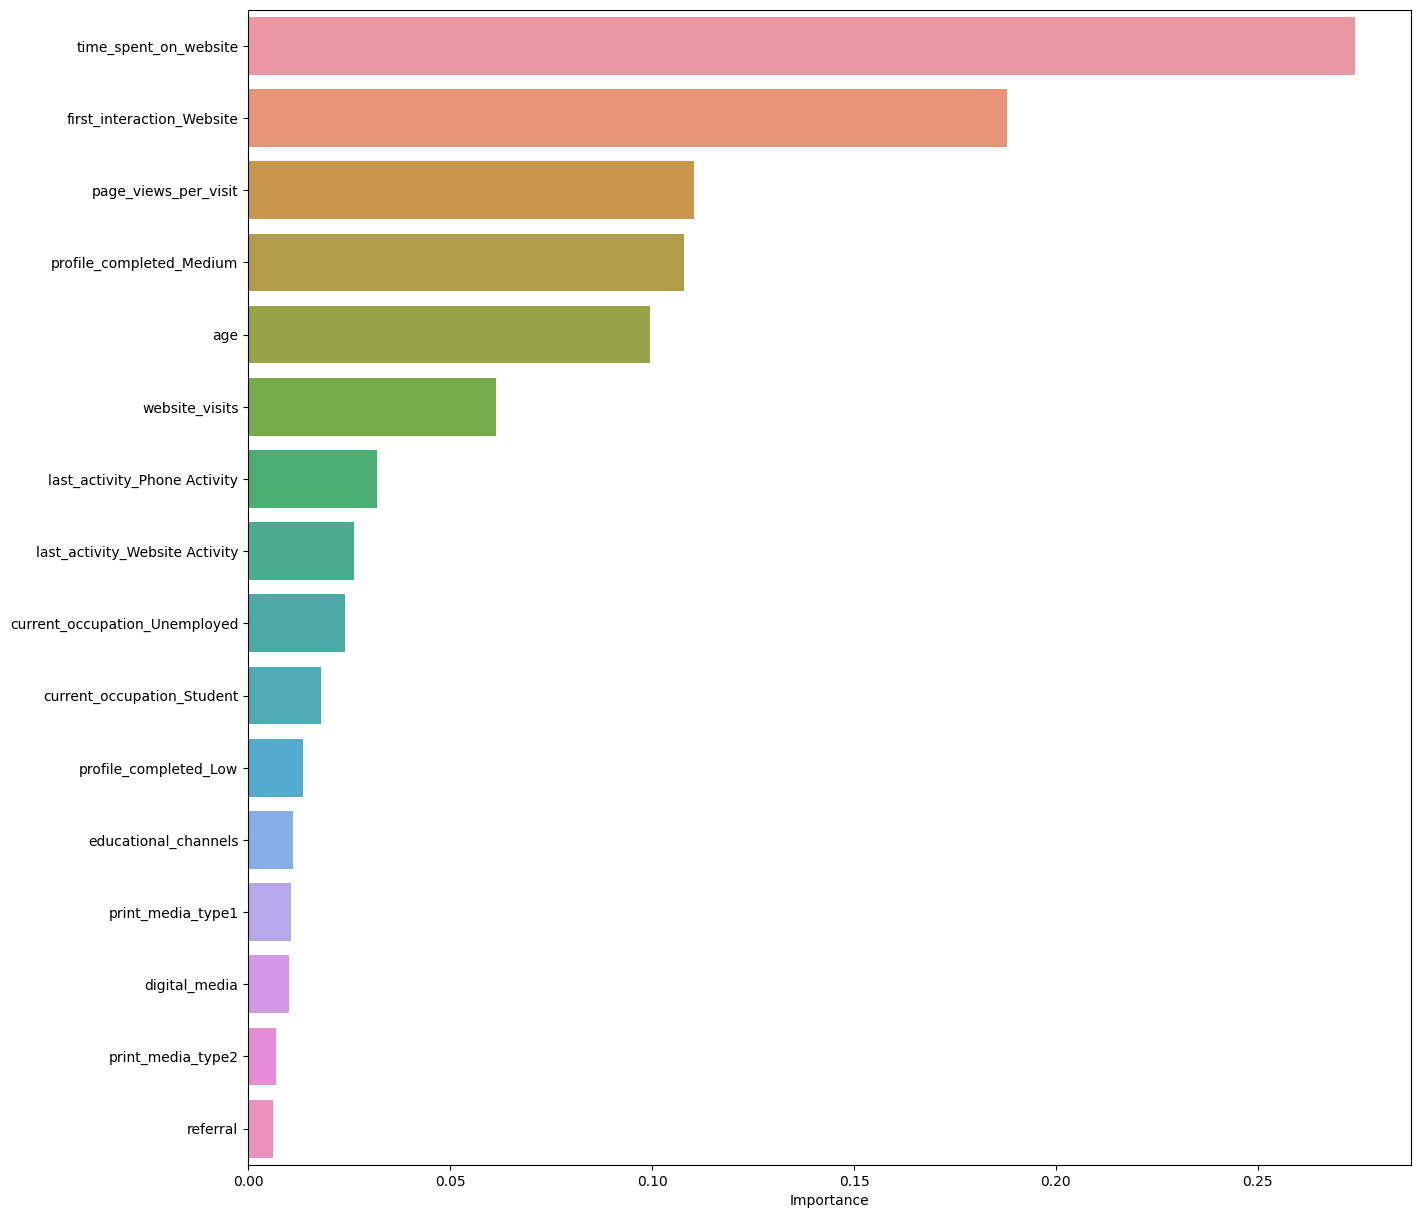

In [58]:
#We see here that the importance features are similar to our default random forest model. This is a good sanity check, because if they were
#drastically different from the decision tree that would be reason for alarm. 
importances = rf_estimator.feature_importances_
columns = X.columns
importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)
plt.figure(figsize = (15, 15))
sns.barplot(x= importance_df.Importance, y=importance_df.index);

In [59]:
#Random forest optimized grid search
rf_estimator_tuned = RandomForestClassifier(class_weight = {0: 0.3, 1: 0.7}, random_state = 1)
# Grid of parameters to search through and choose optimal level
params_rf = {
        "n_estimators": [100, 250, 500],
        "min_samples_leaf": np.arange(1, 4, 1),
        "max_features": [0.7, 0.9, 'auto'],
}
# Type of scoring used to compare parameter combinations - recall score for class 1
scorer = metrics.make_scorer(recall_score, pos_label = 1)
# Grid search to tune the random forest model
grid_obj = GridSearchCV(rf_estimator_tuned, params_rf, scoring = scorer, cv = 5)
grid_obj = grid_obj.fit(x_train, y_train)
# Set the classifier to the best combination of parameters from the grid search
rf_estimator_tuned = grid_obj.best_estimator_

In [60]:
rf_estimator_tuned.fit(x_train, y_train)

RandomForestClassifier(class_weight={0: 0.3, 1: 0.7}, max_features=0.7,
                       min_samples_leaf=3, n_estimators=500, random_state=1)

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      2264
           1       0.88      0.97      0.92       964

    accuracy                           0.95      3228
   macro avg       0.94      0.96      0.94      3228
weighted avg       0.96      0.95      0.95      3228



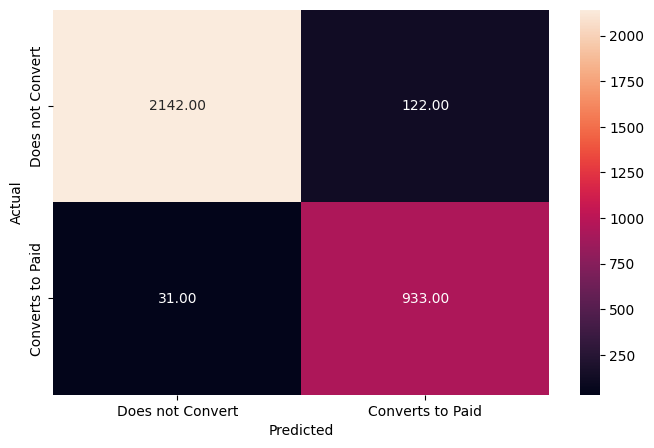

In [61]:
# Running model on training data
y_pred_train_rf_tuned = rf_estimator_tuned.predict(x_train)
metrics_score(y_train, y_pred_train_rf_tuned)

              precision    recall  f1-score   support

           0       0.90      0.88      0.89       971
           1       0.74      0.78      0.76       413

    accuracy                           0.85      1384
   macro avg       0.82      0.83      0.83      1384
weighted avg       0.86      0.85      0.85      1384



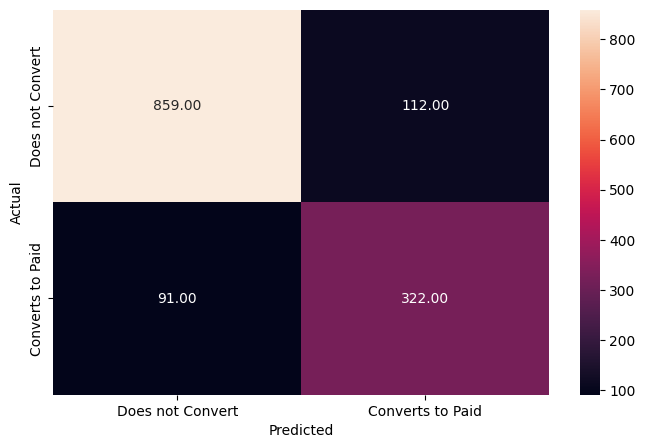

In [62]:
#Runs model on test data
#We see here that precision and recall for status = 1 are both improved from the default random forest model, the tuned random forest is the best fit we
#have seen so far out of all the models.
y_pred_test_rf_tuned = rf_estimator_tuned.predict(x_test)
metrics_score(y_test, y_pred_test_rf_tuned)

In [63]:
#The overall precision and recall are slightly improved in this model compared to the default random forest. The accuracy remains 
#about the same. We conclude that the tuned random forest model is the best prediction method for this dataset.
rf_estimator_tuned_test = model_performance_classification(rf_estimator_tuned,x_test,y_test)
rf_estimator_tuned_test

,Precision,Recall,Accuracy
0,0.823073,0.832158,0.853324


<Axes: xlabel='Importance'>

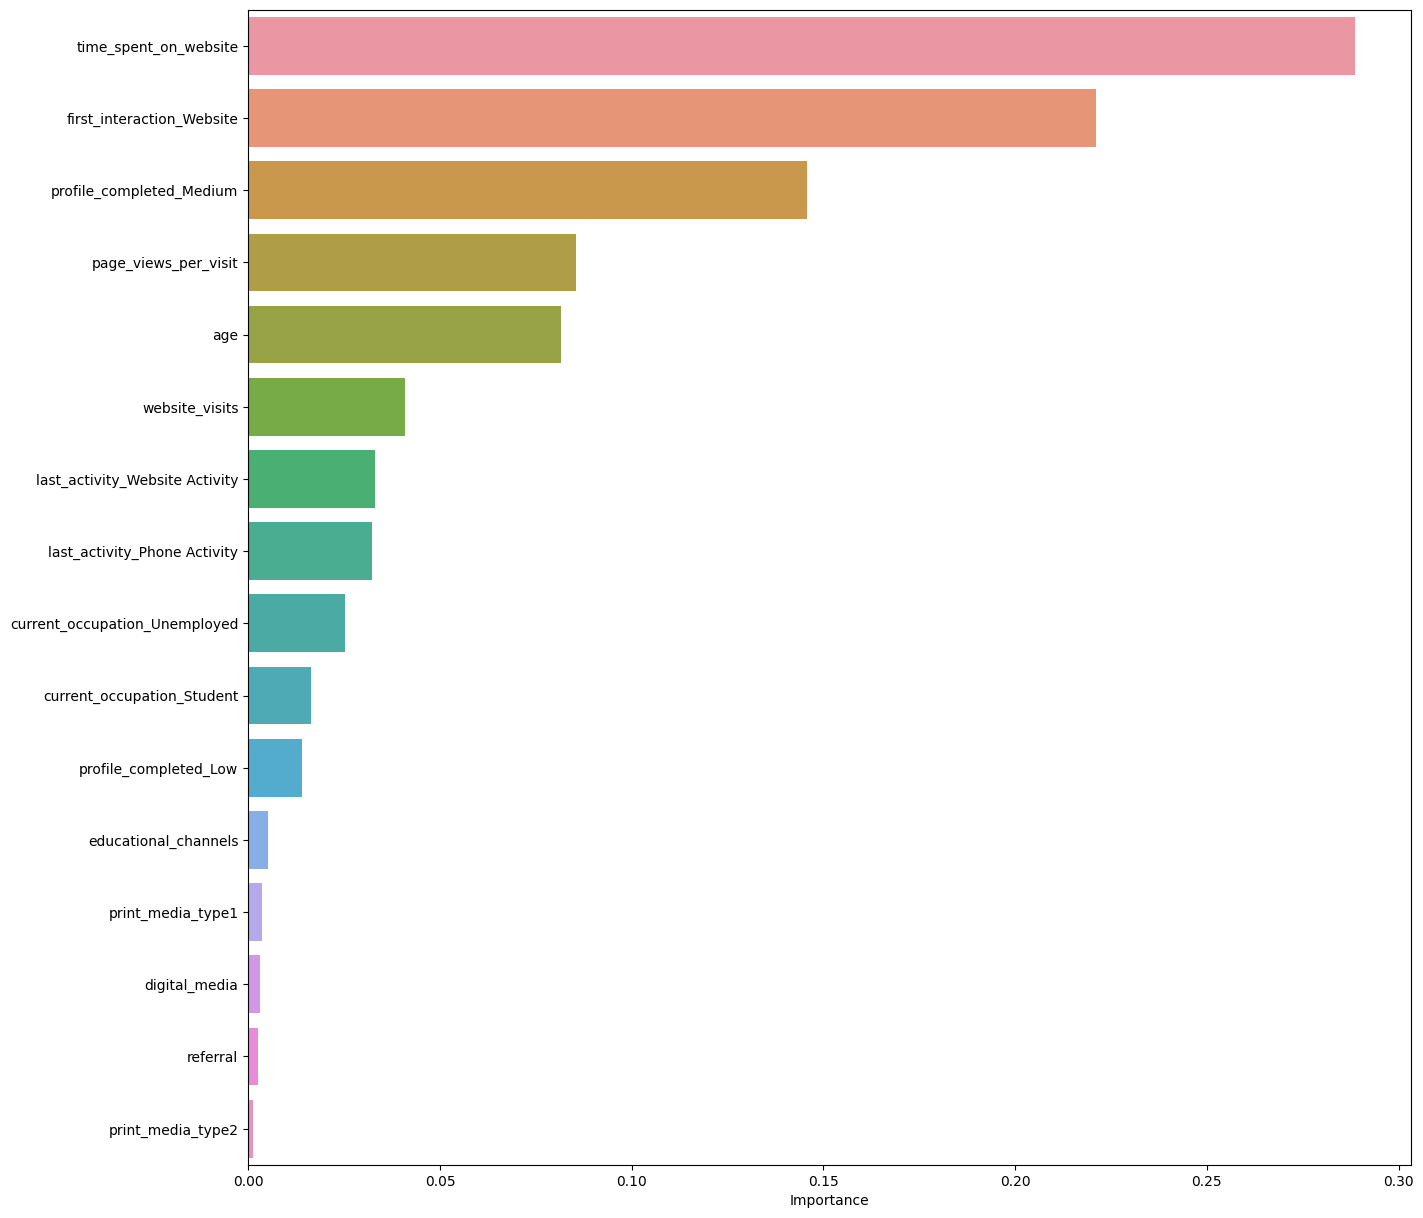

In [64]:
#The feature importance for the tuned random forest model shows that time spent on the website, first interaction, and profile completeness level
#are the most important variables in this model. This is similar to our other importance scores, with time spent on the website and first interaction
#going up a bit. We also see variables like referral and print media type 2 going down in importance from the default random forest.
importances = rf_estimator_tuned.feature_importances_
columns = X.columns
importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)
plt.figure(figsize = (15, 15))
sns.barplot(x= importance_df.Importance, y= importance_df.index)


 ## Observations ##
We can see that the random forest and tuned random forest have higher recall, precision, and accuracy than the decision tree and tuned decision tree models. This indicates that these models are better fit for the dataset.
Time spent on the website is the most important variable to indicate status, followed by the first interaction and profile completeness.
Age is also a determining factor, I will further discuss this variable further in the actionable insights and recommendations section.
Website visits is also a crucial variable, which indicates how active someone is. This can then be helped to detect whether or not they are going to enroll.




# Actionable Insights and Recommendations #
Improve the mobile app: We notice that there's a much lower chance of someone becoming enrolled if they are interacting with the course through the mobile app compared to the website. In order to get a higher level of enrollment through the mobile app, the UI and ease of using the app could be improved to get more people to convert through this channel.

Get a higher number of users to spend more time on the website: The most important variable for all of our models (besides tuned decision tree, which is a bias model), is amount of time spent on the website. We know through the decision tree that the more time someone spends on the website, the more likely they are to enroll. If the company implements incentives such as pre-course material and more course information it could lead to more people spending more time on the website and therefore more conversions.

Since the website has the highest rate of conversion, we should focus on getting users to use this channel and prioritize email and phone outreach to getting users onto the website. An improved mobile app can also help aleviate this blockage.

Expand referral channel: we see that there are a high number of conversions for those that received a referral, but the number of referalls is overall low. Since this seems to be a useful method for conversion, it could be useful to give incentive to users that have already completed the course to refer their friends. This could be utilized as some type of monetary incentive which will create more conversions.

Reach more professionals: Professionals have the highest rate of conversion, so it would be a good idea to market more towards professionals as they have a higher chance of becoming paid users. This could be done by advertising on LinkedIn and other professional sites.

Age targeting: We also see that there is a higher chance someone converts if they are above 27.5 years old. This could be due to a variety of factors such as younger people lacking time, monetary ability, and job flexibility that will allow them to enroll in the class. In order to overcome monetary limitations, the company could offer a lower price for younger folks that may not be able to afford the class but would otherwise enroll. The course could also allow flexibility like recorded lectures and classes during the weekend to help accomodate the younger cohort.

Improved advertisement/marketing: From our EDA, we know that referral and print media 1/2 lead to a higher conversion rate. However, education channels are not seeing the same impact. The company could either improve the education channels to have them advertise more effectively, to a more appropriate audience, or stop this method in effort to redistribute funds towards channels that are leading to higher conversion.

Create liklihood profile: We can take the importance variables from our tuned random forest model that are most likely to predict whether or not a candidate is likely to convert. The company can prioritize those candidates through their advertising channels and help string them along the application process.